**Name:-** Abhishek Lahu Chavan <br/>
**Week:-** 4

In [ ]:
#import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


**Load Dataset**

In [39]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


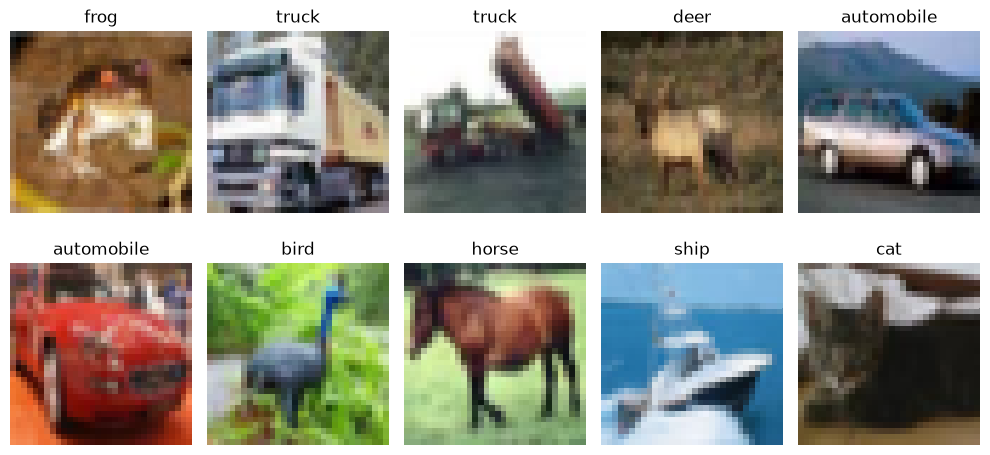

In [40]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

**Preprocessing**

In [41]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## Part1:-ANN  model

In [42]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)




c:\Users\ABHISHEK\Downloads\study material\extra other courses\dspython\myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2709 - loss: 1.9926 - val_accuracy: 0.3476 - val_loss: 1.8205
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3264 - loss: 1.8563 - val_accuracy: 0.3532 - val_loss: 1.7694
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3335 - loss: 1.8142 - val_accuracy: 0.3888 - val_loss: 1.7116
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3523 - loss: 1.7767 - val_accuracy: 0.4022 - val_loss: 1.7188
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3638 - loss: 1.7472 - val_accuracy: 0.4118 - val_loss: 1.6802
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3762 - loss: 1.7219 - val_accuracy: 0.4030 - val_loss: 1.6779
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3789 - loss: 1.7133 - val_accuracy: 0.4124 - val_loss: 1.6682
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3851 - loss: 1.6904 - val_accu

In [43]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4216 - loss: 1.6510
ANN Test Accuracy: 0.42160001397132874


## Part2:-CNN model

In [44]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\ABHISHEK\Downloads\study material\extra other courses\dspython\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4597 - loss: 1.4981 - val_accuracy: 0.4292 - val_loss: 2.0076
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6086 - loss: 1.1227 - val_accuracy: 0.5152 - val_loss: 1.4422
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.6745 - loss: 0.9358 - val_accuracy: 0.4238 - val_loss: 2.2867
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7152 - loss: 0.8177 - val_accuracy: 0.6120 - val_loss: 1.2001
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7466 - loss: 0.7277 - val_accuracy: 0.6720 - val_loss: 0.9667
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7698 - loss: 0.6545 - val_accuracy: 0.7158 - val_loss: 0.8250
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7938 - loss: 0.5832 - val_accuracy: 0.6750 - val_loss: 1.0199
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8156 - loss: 0.5219 - 

In [45]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6300 - loss: 1.3709
CNN Test Accuracy: 0.6299999952316284


**Comparing Learning objectives**

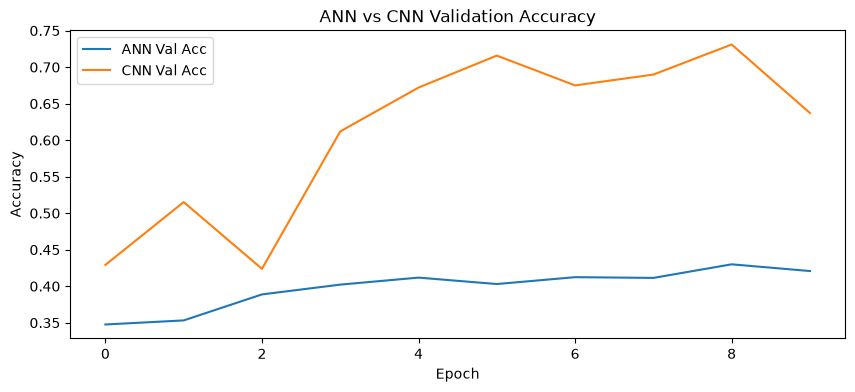

In [46]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3768 - loss: 1.7128 - val_accuracy: 0.4988 - val_loss: 1.3645
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.4661 - loss: 1.4826 - val_accuracy: 0.5422 - val_loss: 1.2820
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.5033 - loss: 1.3888 - val_accuracy: 0.5732 - val_loss: 1.2041
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.5289 - loss: 1.3292 - val_accuracy: 0.5794 - val_loss: 1.2019
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.5436 - loss: 1.2880 - val_accuracy: 0.5918 - val_loss: 1.1591
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5559 - loss: 1.2550 - val_accuracy: 0.6196 - val_loss: 1.0781
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5671 - loss: 1.2280 - val_accuracy: 0.6288 - val_loss: 1.0622
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.5711 -

In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm,y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6401 - loss: 1.0266
Augmented CNN Test Accuracy: 0.6401000022888184
Augmented CNN Test Loss: 1.0265743732452393


**Comparison Table**

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]})
comparison


,Model,Test Accuracy
0,ANN,0.4216
1,CNN,0.6300


## Increased ANN  layers

In [ ]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)




c:\Users\ABHISHEK\Downloads\study material\extra other courses\dspython\myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.2509 - loss: 2.0194 - val_accuracy: 0.3290 - val_loss: 1.8616
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3087 - loss: 1.8794 - val_accuracy: 0.3488 - val_loss: 1.8245
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3241 - loss: 1.8417 - val_accuracy: 0.3476 - val_loss: 1.8258
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3419 - loss: 1.8056 - val_accuracy: 0.3752 - val_loss: 1.7525
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3506 - loss: 1.7814 - val_accuracy: 0.3996 - val_loss: 1.7130
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3599 - loss: 1.7613 - val_accuracy: 0.4020 - val_loss: 1.6883
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3692 - loss: 1.7388 - val_accuracy: 0.4056 - val_loss: 1.6884
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3755 - loss: 1.7234 - 

In [51]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3993 - loss: 1.6879
ANN Test Accuracy: 0.3993000090122223


## Increase epochs

In [52]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3875 - loss: 1.6855 - val_accuracy: 0.4188 - val_loss: 1.6602
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3946 - loss: 1.6719 - val_accuracy: 0.4226 - val_loss: 1.6369
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3960 - loss: 1.6698 - val_accuracy: 0.4334 - val_loss: 1.6097
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.3987 - loss: 1.6637 - val_accuracy: 0.4264 - val_loss: 1.6228
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4009 - loss: 1.6493 - val_accuracy: 0.4338 - val_loss: 1.6153
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.4057 - loss: 1.6467 - val_accuracy: 0.4398 - val_loss: 1.5970
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4083 - loss: 1.6379 - val_accuracy: 0.4296 - val_loss: 1.6210
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4088 - loss: 1.6342 - 

In [53]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4549 - loss: 1.5420
ANN Test Accuracy: 0.45489999651908875


In [54]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8636 - loss: 0.3818 - val_accuracy: 0.7270 - val_loss: 0.9865
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.8747 - loss: 0.3518 - val_accuracy: 0.7096 - val_loss: 1.0505
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.8844 - loss: 0.3260 - val_accuracy: 0.6950 - val_loss: 1.1421
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8917 - loss: 0.3046 - val_accuracy: 0.7288 - val_loss: 1.0337
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8984 - loss: 0.2806 - val_accuracy: 0.7488 - val_loss: 0.9603
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9076 - loss: 0.2607 - val_accuracy: 0.7370 - val_loss: 1.1245
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9110 - loss: 0.2528 - val_accuracy: 0.6898 - val_loss: 1.3082
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9151 - loss: 0.2395 - 

In [55]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7173 - loss: 1.7038
CNN Test Accuracy: 0.7172999978065491


In [56]:
aug_history = aug_cnn_model.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6053 - loss: 1.1157 - val_accuracy: 0.6672 - val_loss: 0.9550
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6056 - loss: 1.1137 - val_accuracy: 0.6600 - val_loss: 0.9820
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.6098 - loss: 1.1063 - val_accuracy: 0.6548 - val_loss: 0.9758
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6158 - loss: 1.0988 - val_accuracy: 0.6438 - val_loss: 1.0233
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6160 - loss: 1.0927 - val_accuracy: 0.6500 - val_loss: 1.0041
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6188 - loss: 1.0868 - val_accuracy: 0.6706 - val_loss: 0.9515
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6219 - loss: 1.0762 - val_accuracy: 0.6434 - val_loss: 1.0271
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6277 - loss: 1.0683 - 

## Added early Stopping

In [57]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

In [58]:
history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8984 - loss: 0.3049 - val_accuracy: 0.7070 - val_loss: 1.4803
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9139 - loss: 0.2509 - val_accuracy: 0.7188 - val_loss: 1.3774
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.9187 - loss: 0.2335 - val_accuracy: 0.7386 - val_loss: 1.2728
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.9238 - loss: 0.2190 - val_accuracy: 0.6912 - val_loss: 1.7568
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.9263 - loss: 0.2134 - val_accuracy: 0.7030 - val_loss: 1.5487
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.9284 - loss: 0.2084 - val_accuracy: 0.7280 - val_loss: 1.3279


## Data Augmentation training

In [59]:
aug_history = aug_cnn_model.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64,callbacks=[early_stop])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6442 - loss: 1.0119 - val_accuracy: 0.6856 - val_loss: 0.9030
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6458 - loss: 1.0077 - val_accuracy: 0.6934 - val_loss: 0.8834
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6466 - loss: 1.0070 - val_accuracy: 0.6800 - val_loss: 0.9166
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6495 - loss: 1.0019 - val_accuracy: 0.6694 - val_loss: 0.9510
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6513 - loss: 0.9918 - val_accuracy: 0.6822 - val_loss: 0.9208


In [60]:
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm,y_test)
print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6839 - loss: 0.9091
Augmented CNN Accuracy: 0.683899998664856


In [61]:
comparison = pd.DataFrame({
    "Model": [
"ANN",
        "CNN",
        "CNN + Data Augmentation"],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_acc]
})

comparison

,Model,Accuracy
0,ANN,0.4549
1,CNN,0.7173
2,CNN + Data Augmentation,0.6839


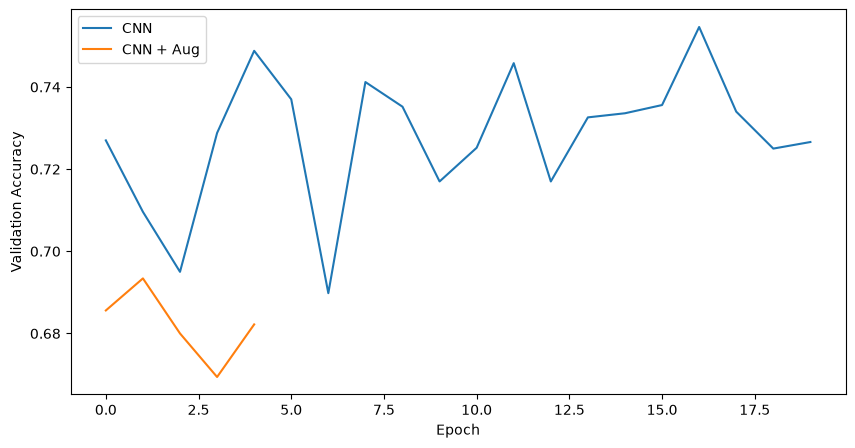

In [62]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'],label='CNN + Aug')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.show()